In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set parameters
data_dir = "/content/drive/MyDrive/Dataset"
img_size = (224, 224)
batch_size = 32

In [ ]:
# Load dataset with split
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # training 80%, keeping the 20% for validation
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int"  # for multi-class classification
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # using the 20% for val
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int"
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 22036 files belonging to 4 classes.
Using 17629 files for training.
Found 22036 files belonging to 4 classes.
Using 4407 files for validation.
Class names: ['Benign', 'Early Pre-B-ALL', 'Pre-B-ALL', 'Pro B-ALL']


In [ ]:
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    print("Sample labels:", labels[:10].numpy())  # first 10 labels


Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32,)
Sample labels: [3 3 0 0 1 0 2 2 0 3]


In [ ]:
for images, labels in train_ds.take(1):
    print("Label dtype:", labels.dtype)
    print("Unique labels:", tf.unique(labels).y.numpy() if len(labels.shape)==1 else "One-hot encoded")


Label dtype: <dtype: 'int32'>
Unique labels: [2 3 1 0]


Pre-Processing and Data augmentation is already applied

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
      weights='imagenet',  # Use pre-trained weights from ImageNet
      include_top=False,  # Exclude the top (classification) layer
      input_shape=(224, 224, 3)  # the input shape
  )
base_model.trainable = False  # Freeze the base model's weights

# the CNN model
model = tf.keras.Sequential([
    keras.Input(shape=(img_size[0], img_size[1], 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,           # stop if val_loss doesn’t improve for 8 epochs
    restore_best_weights=True
)

# Reduce learning rate when plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,           # reduce LR by 20%
    patience=3,           # wait 3 epochs before reducing LR
    min_lr=1e-6
)


In [ ]:
# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs= 30,callbacks=[early_stopping, reduce_lr],
    verbose=1)

Epoch 1/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 119s 167ms/step - accuracy: 0.4634 - loss: 1.8127 - val_accuracy: 0.6962 - val_loss: 1.1595 - learning_rate: 1.0000e-04
Epoch 2/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.6795 - loss: 1.1922 - val_accuracy: 0.7502 - val_loss: 0.9566 - learning_rate: 1.0000e-04
Epoch 3/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.7397 - loss: 1.0078 - val_accuracy: 0.7899 - val_loss: 0.8441 - learning_rate: 1.0000e-04
Epoch 4/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.7689 - loss: 0.9017 - val_accuracy: 0.8167 - val_loss: 0.7627 - learning_rate: 1.0000e-04
Epoch 5/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.7889 - loss: 0.8257 - val_accuracy: 0.8355 - val_loss: 0.7045 - learning_rate: 1.0000e-04
Epoch 6/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.8024 - loss: 0.7716 - val_accuracy: 0.8452 - val_loss: 0.6599 - learning_rate: 1.0000e-04
Epoch 7/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/s

In [ ]:
model.save("mobilenetv2_all.keras")

In [ ]:
# Save the entire model
import os
os.makedirs('/content/drive/MyDrive/mobilenet', exist_ok=True)
model.save("2mobilenetv2_all.keras")

In [ ]:
import os
#os.makedirs('/content/drive/MyDrive/mobilenet', exist_ok=True)
# for fast api
#save_path = '/content/drive/MyDrive/mobilenet'
model.save('2mobilenetv2_all.h5')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/mobilenet/mobilenetv2_all.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


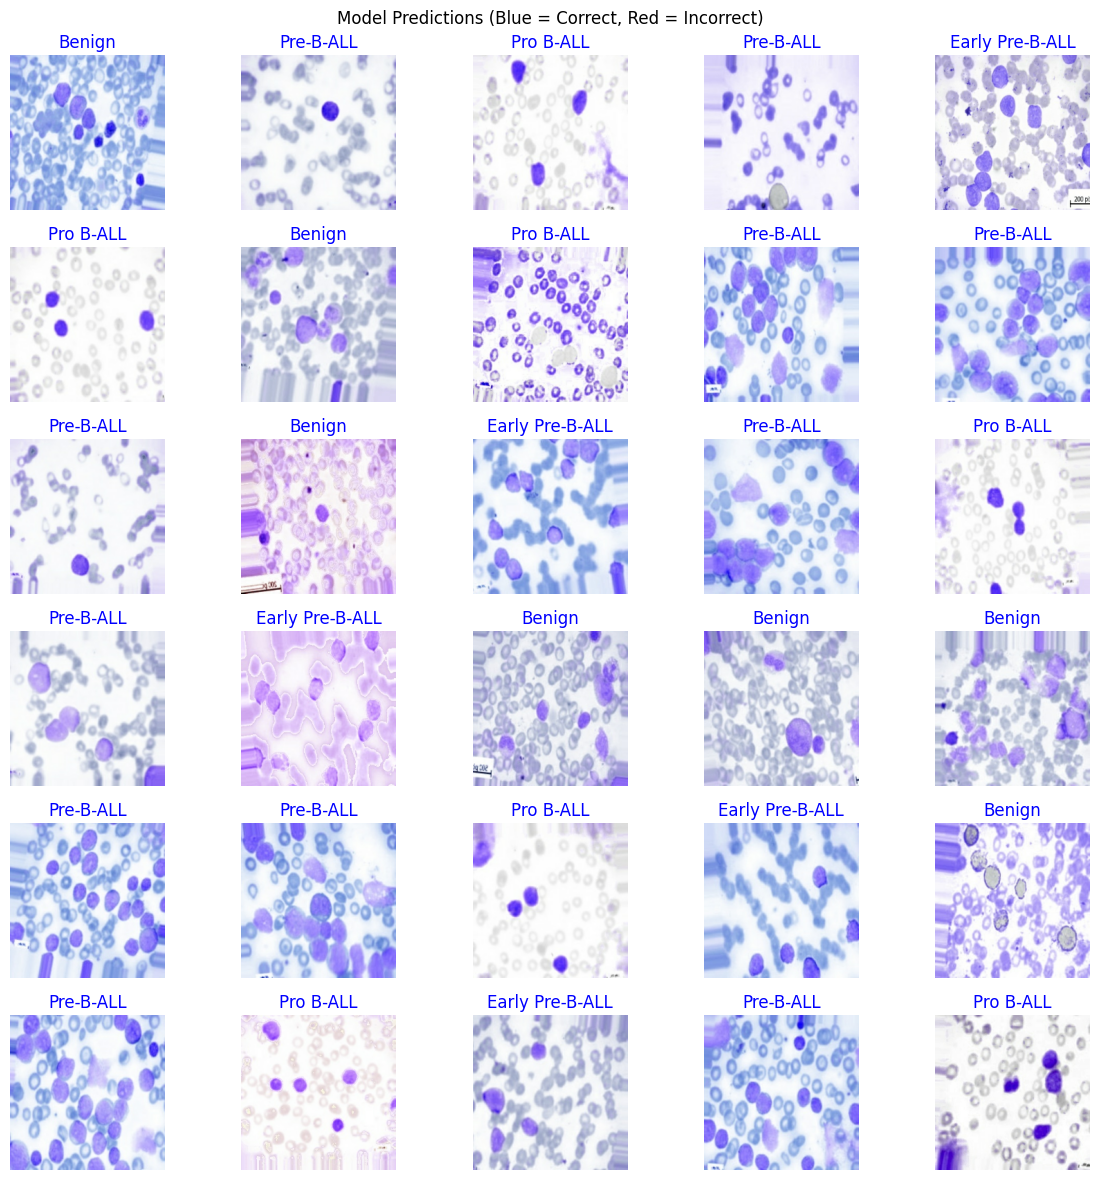

In [ ]:
# Prediction visualization
image_batch, label_batch = next(iter(train_ds.take(1)))
predicted_batch = model.predict(image_batch)
predicted_ids = np.argmax(predicted_batch, axis=-1)
predicted_class_names = [class_names[i] for i in predicted_ids]

# Plot predictions
plt.figure(figsize=(12, 12))
for n in range(min(30, len(image_batch))):
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n].numpy().astype("uint8"))
    color = "blue" if predicted_ids[n] == label_batch[n].numpy() else "red"
    plt.title(predicted_class_names[n], color=color)
    plt.axis('off')
plt.suptitle("Model Predictions (Blue = Correct, Red = Incorrect)")
plt.tight_layout()
plt.show()


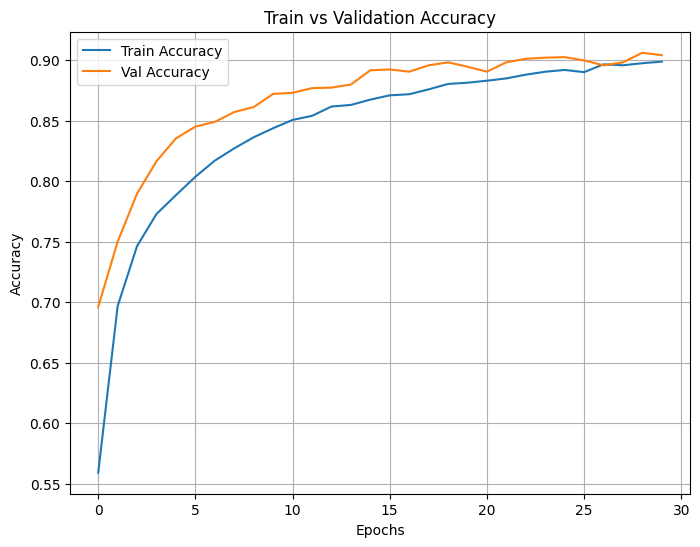

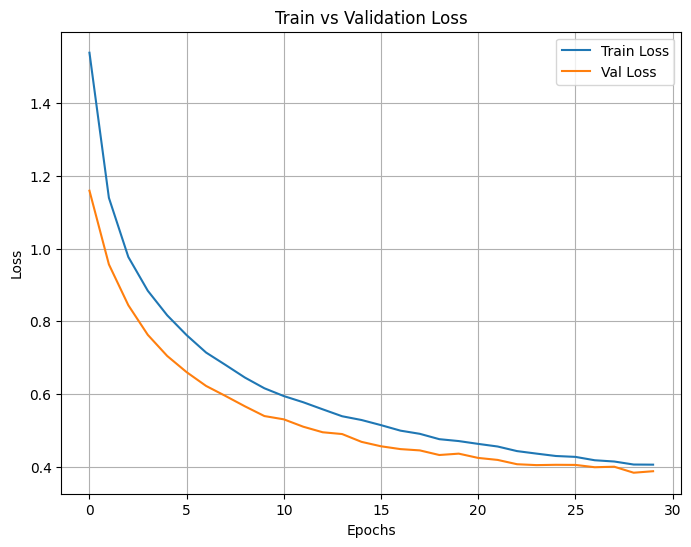

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("train_vs_val_accuracy.png")
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig("Train vs Validation Loss.png")
plt.show()


/tmp/ipython-input-4155074125.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


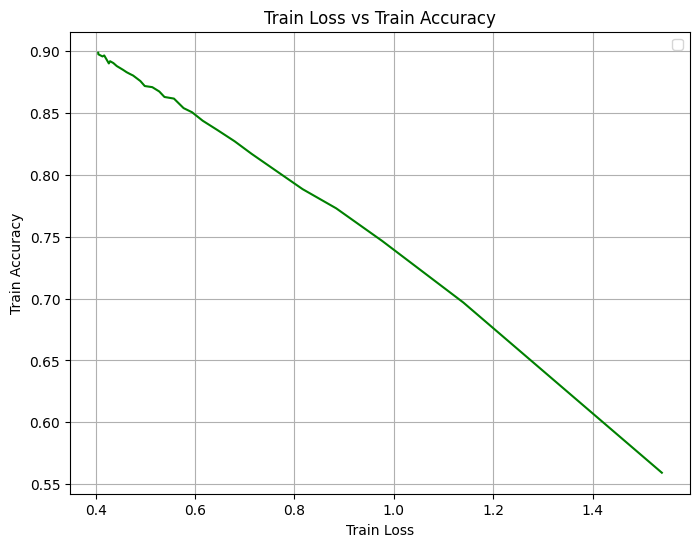

/tmp/ipython-input-4155074125.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


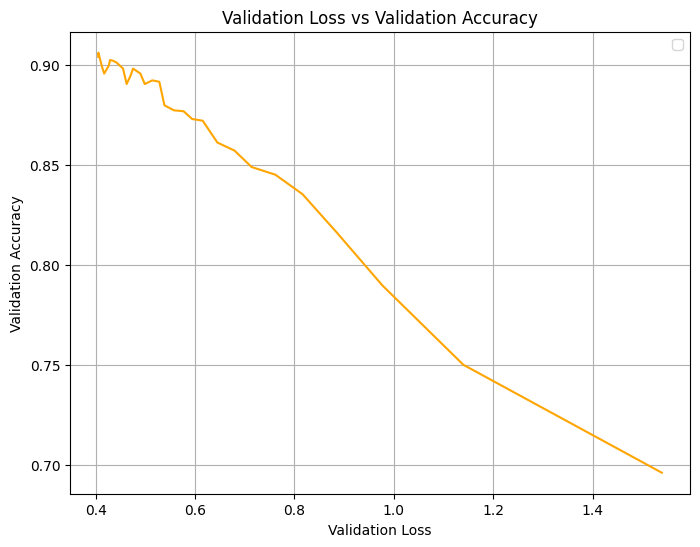

In [ ]:
# Plot: Train loss vs Train accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], history.history['accuracy'], color='green')
plt.xlabel('Train Loss')
plt.ylabel('Train Accuracy')
plt.title('Train Loss vs Train Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("train_loss_vs_train_accuracy.png")
plt.show()

# Plot: val loss vs Val accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], history.history['val_accuracy'], color='orange')
plt.xlabel('Validation Loss')
plt.ylabel('Validation Accuracy')
plt.title('Validation Loss vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("val_acc_vs_val_loss.png")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

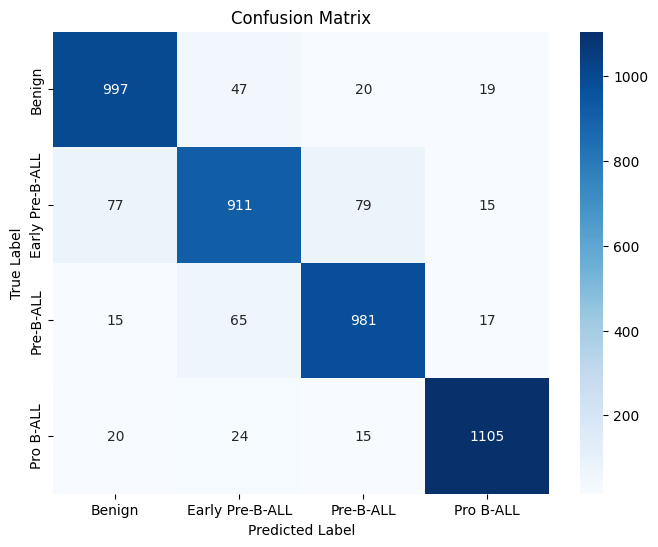

Classification Report:
               precision    recall  f1-score   support

  all_benign       0.90      0.92      0.91      1083
   all_early       0.87      0.84      0.86      1082
     all_pre       0.90      0.91      0.90      1078
     all_pro       0.96      0.95      0.95      1164

    accuracy                           0.91      4407
   macro avg       0.91      0.91      0.91      4407
weighted avg       0.91      0.91      0.91      4407

Classification Report:

                 precision    recall  f1-score   support

         Benign     0.8990    0.9206    0.9097      1083
Early Pre-B-ALL     0.8701    0.8420    0.8558      1082
      Pre-B-ALL     0.8959    0.9100    0.9029      1078
      Pro B-ALL     0.9559    0.9493    0.9526      1164

       accuracy                         0.9063      4407
      macro avg     0.9052    0.9055    0.9052      4407
   weighted avg     0.9062    0.9063    0.9061      4407



<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# class in tf_flowers
class_name = ['all_benign', 'all_early', 'all_pre', 'all_pro']

# Get true labels and predictions
y_true = []
y_pred = []


for images, labels in val_ds:
    predictions = model.predict(images)  # Get predicted probabilities
    y_true.extend(labels.numpy())  # Store true labels
    y_pred.extend(np.argmax(predictions,axis=1))  # Convert probs to class labels using argmax
# grabs the index of the class with highest probability, for each image.

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred) #compares predictions vs. true labels.

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names = class_name))
#classification_report() — gives precision, recall, and F1-score per class

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
plt.savefig("confusion_matrix.png")
print(report)


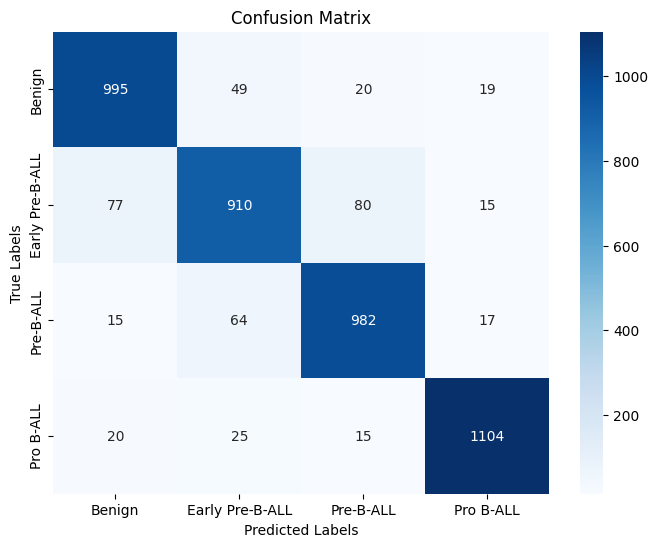

Classification Report:

                 precision    recall  f1-score   support

         Benign     0.8988    0.9187    0.9087      1083
Early Pre-B-ALL     0.8683    0.8410    0.8545      1082
      Pre-B-ALL     0.8952    0.9109    0.9030      1078
      Pro B-ALL     0.9558    0.9485    0.9521      1164

       accuracy                         0.9056      4407
      macro avg     0.9045    0.9048    0.9046      4407
   weighted avg     0.9055    0.9056    0.9055      4407



<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions from the validation set
y_true = []
y_pred = []

for images, labels in val_ds.unbatch():
    y_true.append(int(labels.numpy()))
    preds = model.predict(tf.expand_dims(images, axis=0), verbose=0)
    y_pred.append(np.argmax(preds))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
plt.savefig("confusion_matrix.png")
print(report)


In [ ]:
# Print precision, recall, f1-score, support
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)

# Optional: Save report to .txt file
with open("classification_report.txt", "w") as f:
    f.write(report)


Classification Report:

                 precision    recall  f1-score   support

         Benign     0.8988    0.9187    0.9087      1083
Early Pre-B-ALL     0.8683    0.8410    0.8545      1082
      Pre-B-ALL     0.8952    0.9109    0.9030      1078
      Pro B-ALL     0.9558    0.9485    0.9521      1164

       accuracy                         0.9056      4407
      macro avg     0.9045    0.9048    0.9046      4407
   weighted avg     0.9055    0.9056    0.9055      4407



In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/mobilenet/mobilenetv2_all.keras")

In [ ]:
# Train the model
history2 = model.fit(train_ds, validation_data=val_ds, epochs= 15,callbacks=[early_stopping, reduce_lr],
    verbose=1)

Epoch 1/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 1162s 2s/step - accuracy: 0.7385 - loss: 0.8927 - val_accuracy: 0.8239 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 2/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.7790 - loss: 0.6685 - val_accuracy: 0.8366 - val_loss: 0.5040 - learning_rate: 0.0010
Epoch 3/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.7898 - loss: 0.6264 - val_accuracy: 0.8055 - val_loss: 0.5800 - learning_rate: 0.0010
Epoch 4/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8009 - loss: 0.6130 - val_accuracy: 0.8269 - val_loss: 0.5299 - learning_rate: 0.0010
Epoch 5/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8090 - loss: 0.5983 - val_accuracy: 0.8414 - val_loss: 0.4865 - learning_rate: 0.0010
Epoch 6/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8130 - loss: 0.5994 - val_accuracy: 0.8548 - val_loss: 0.4594 - learning_rate: 0.0010
Epoch 7/15
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8052 - l